# EDA for work from home burnout prediction 

In [7]:
 import numpy as np 
 import pandas as pd 
 import seaborn as sns

In [8]:
df = pd.read_csv('work_from_home_burnout_dataset.csv')

In [9]:
df

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low
...,...,...,...,...,...,...,...,...,...,...,...
1795,180,Weekend,6.33,8.16,0,4,0,5.59,73.5,31.91,Low
1796,180,Weekend,4.70,7.88,0,4,0,6.69,89.8,26.30,Low
1797,180,Weekend,3.92,6.39,2,1,0,6.77,74.6,34.07,Low
1798,180,Weekday,8.93,11.11,2,5,0,8.28,74.6,38.14,Low


In [10]:
df.shape

(1800, 11)

In [11]:
df.isna().sum()

user_id                 0
day_type                0
work_hours              0
screen_time_hours       0
meetings_count          0
breaks_taken            0
after_hours_work        0
sleep_hours             0
task_completion_rate    0
burnout_score           0
burnout_risk            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1800 non-null   int64  
 1   day_type              1800 non-null   object 
 2   work_hours            1800 non-null   float64
 3   screen_time_hours     1800 non-null   float64
 4   meetings_count        1800 non-null   int64  
 5   breaks_taken          1800 non-null   int64  
 6   after_hours_work      1800 non-null   int64  
 7   sleep_hours           1800 non-null   float64
 8   task_completion_rate  1800 non-null   float64
 9   burnout_score         1800 non-null   float64
 10  burnout_risk          1800 non-null   object 
dtypes: float64(5), int64(4), object(2)
memory usage: 154.8+ KB


In [12]:
df.nunique()

user_id                  180
day_type                   2
work_hours               689
screen_time_hours        785
meetings_count            11
breaks_taken               5
after_hours_work           2
sleep_hours              452
task_completion_rate     520
burnout_score           1603
burnout_risk               3
dtype: int64

In [13]:
df.describe()

,user_id,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,90.500000,6.515117,9.271406,1.941111,3.028889,0.358889,6.996467,72.308556,44.009978
std,51.975162,2.290521,2.409253,1.696178,1.417844,0.479808,1.061740,14.978647,23.881782
min,1.000000,3.000000,4.510000,0.000000,1.000000,0.000000,4.500000,40.000000,2.500000
25%,45.750000,4.430000,7.240000,1.000000,2.000000,0.000000,6.280000,62.300000,25.370000
50%,90.500000,6.445000,9.210000,2.000000,3.000000,0.000000,6.990000,74.500000,39.270000
75%,135.250000,8.510000,11.310000,3.000000,4.000000,1.000000,7.750000,83.700000,58.197500
max,180.000000,12.170000,15.700000,10.000000,5.000000,1.000000,10.800000,107.200000,143.920000


In [15]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

In [16]:
skew_before = df[num_cols].skew()
# Display skewness values
skew_before.sort_values(ascending=False)

skew_df = pd.DataFrame({
    'Feature': num_cols,
    'Skewness_Before_Imputation': df[num_cols].skew().values
})

skew_df.sort_values(by='Skewness_Before_Imputation', ascending=False)


,Feature,Skewness_Before_Imputation
3,meetings_count,0.999487
8,burnout_score,0.866536
5,after_hours_work,0.588853
2,screen_time_hours,0.086803
1,work_hours,0.080079
6,sleep_hours,0.052088
0,user_id,0.000000
4,breaks_taken,-0.052221
7,task_completion_rate,-0.472326


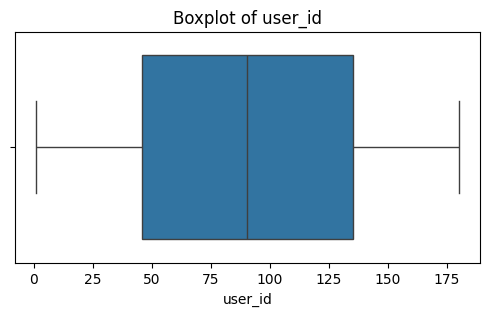

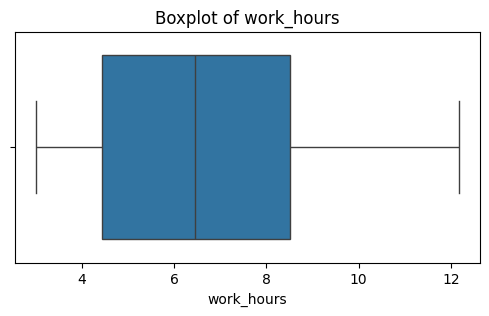

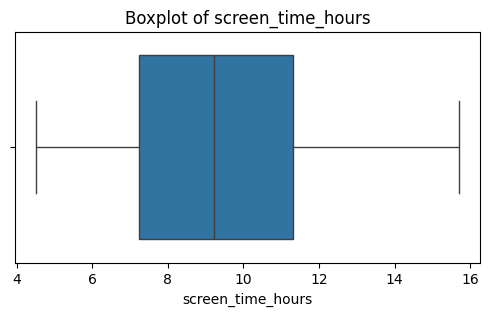

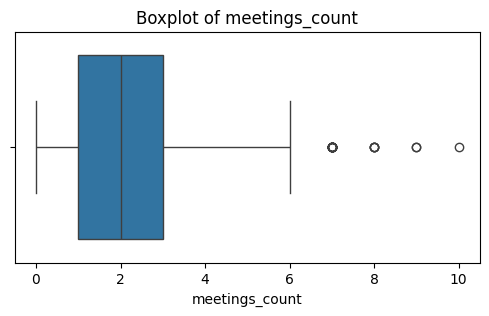

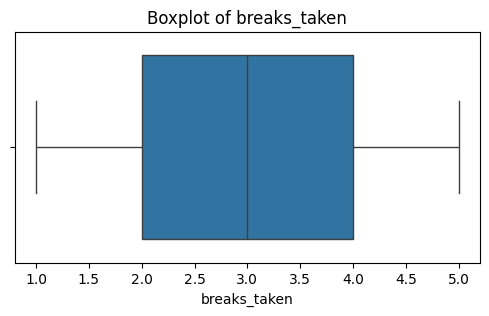

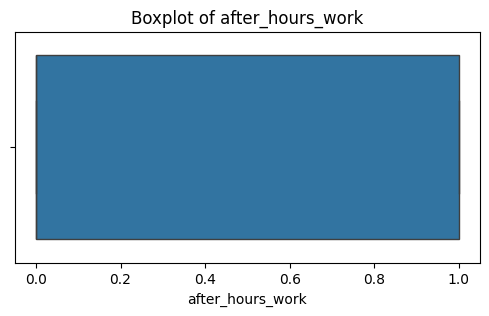

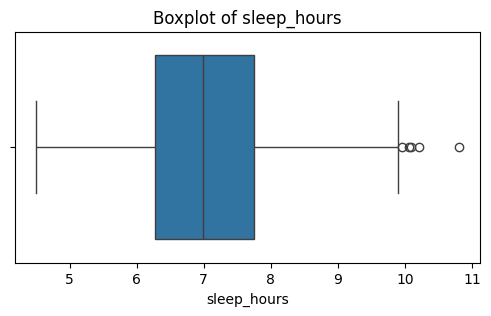

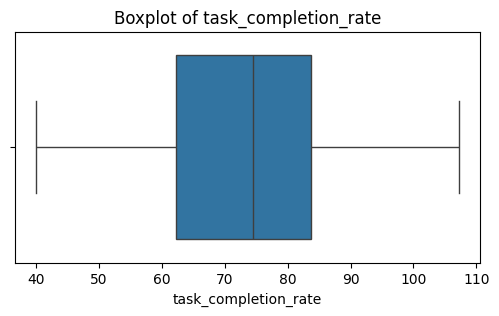

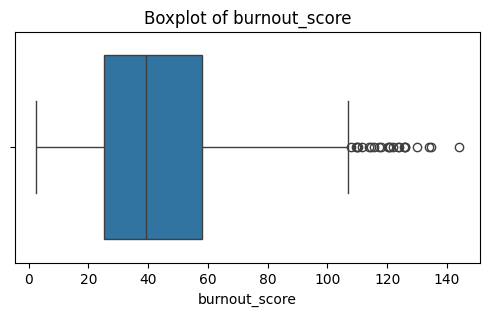

In [17]:

import matplotlib.pyplot as plt
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


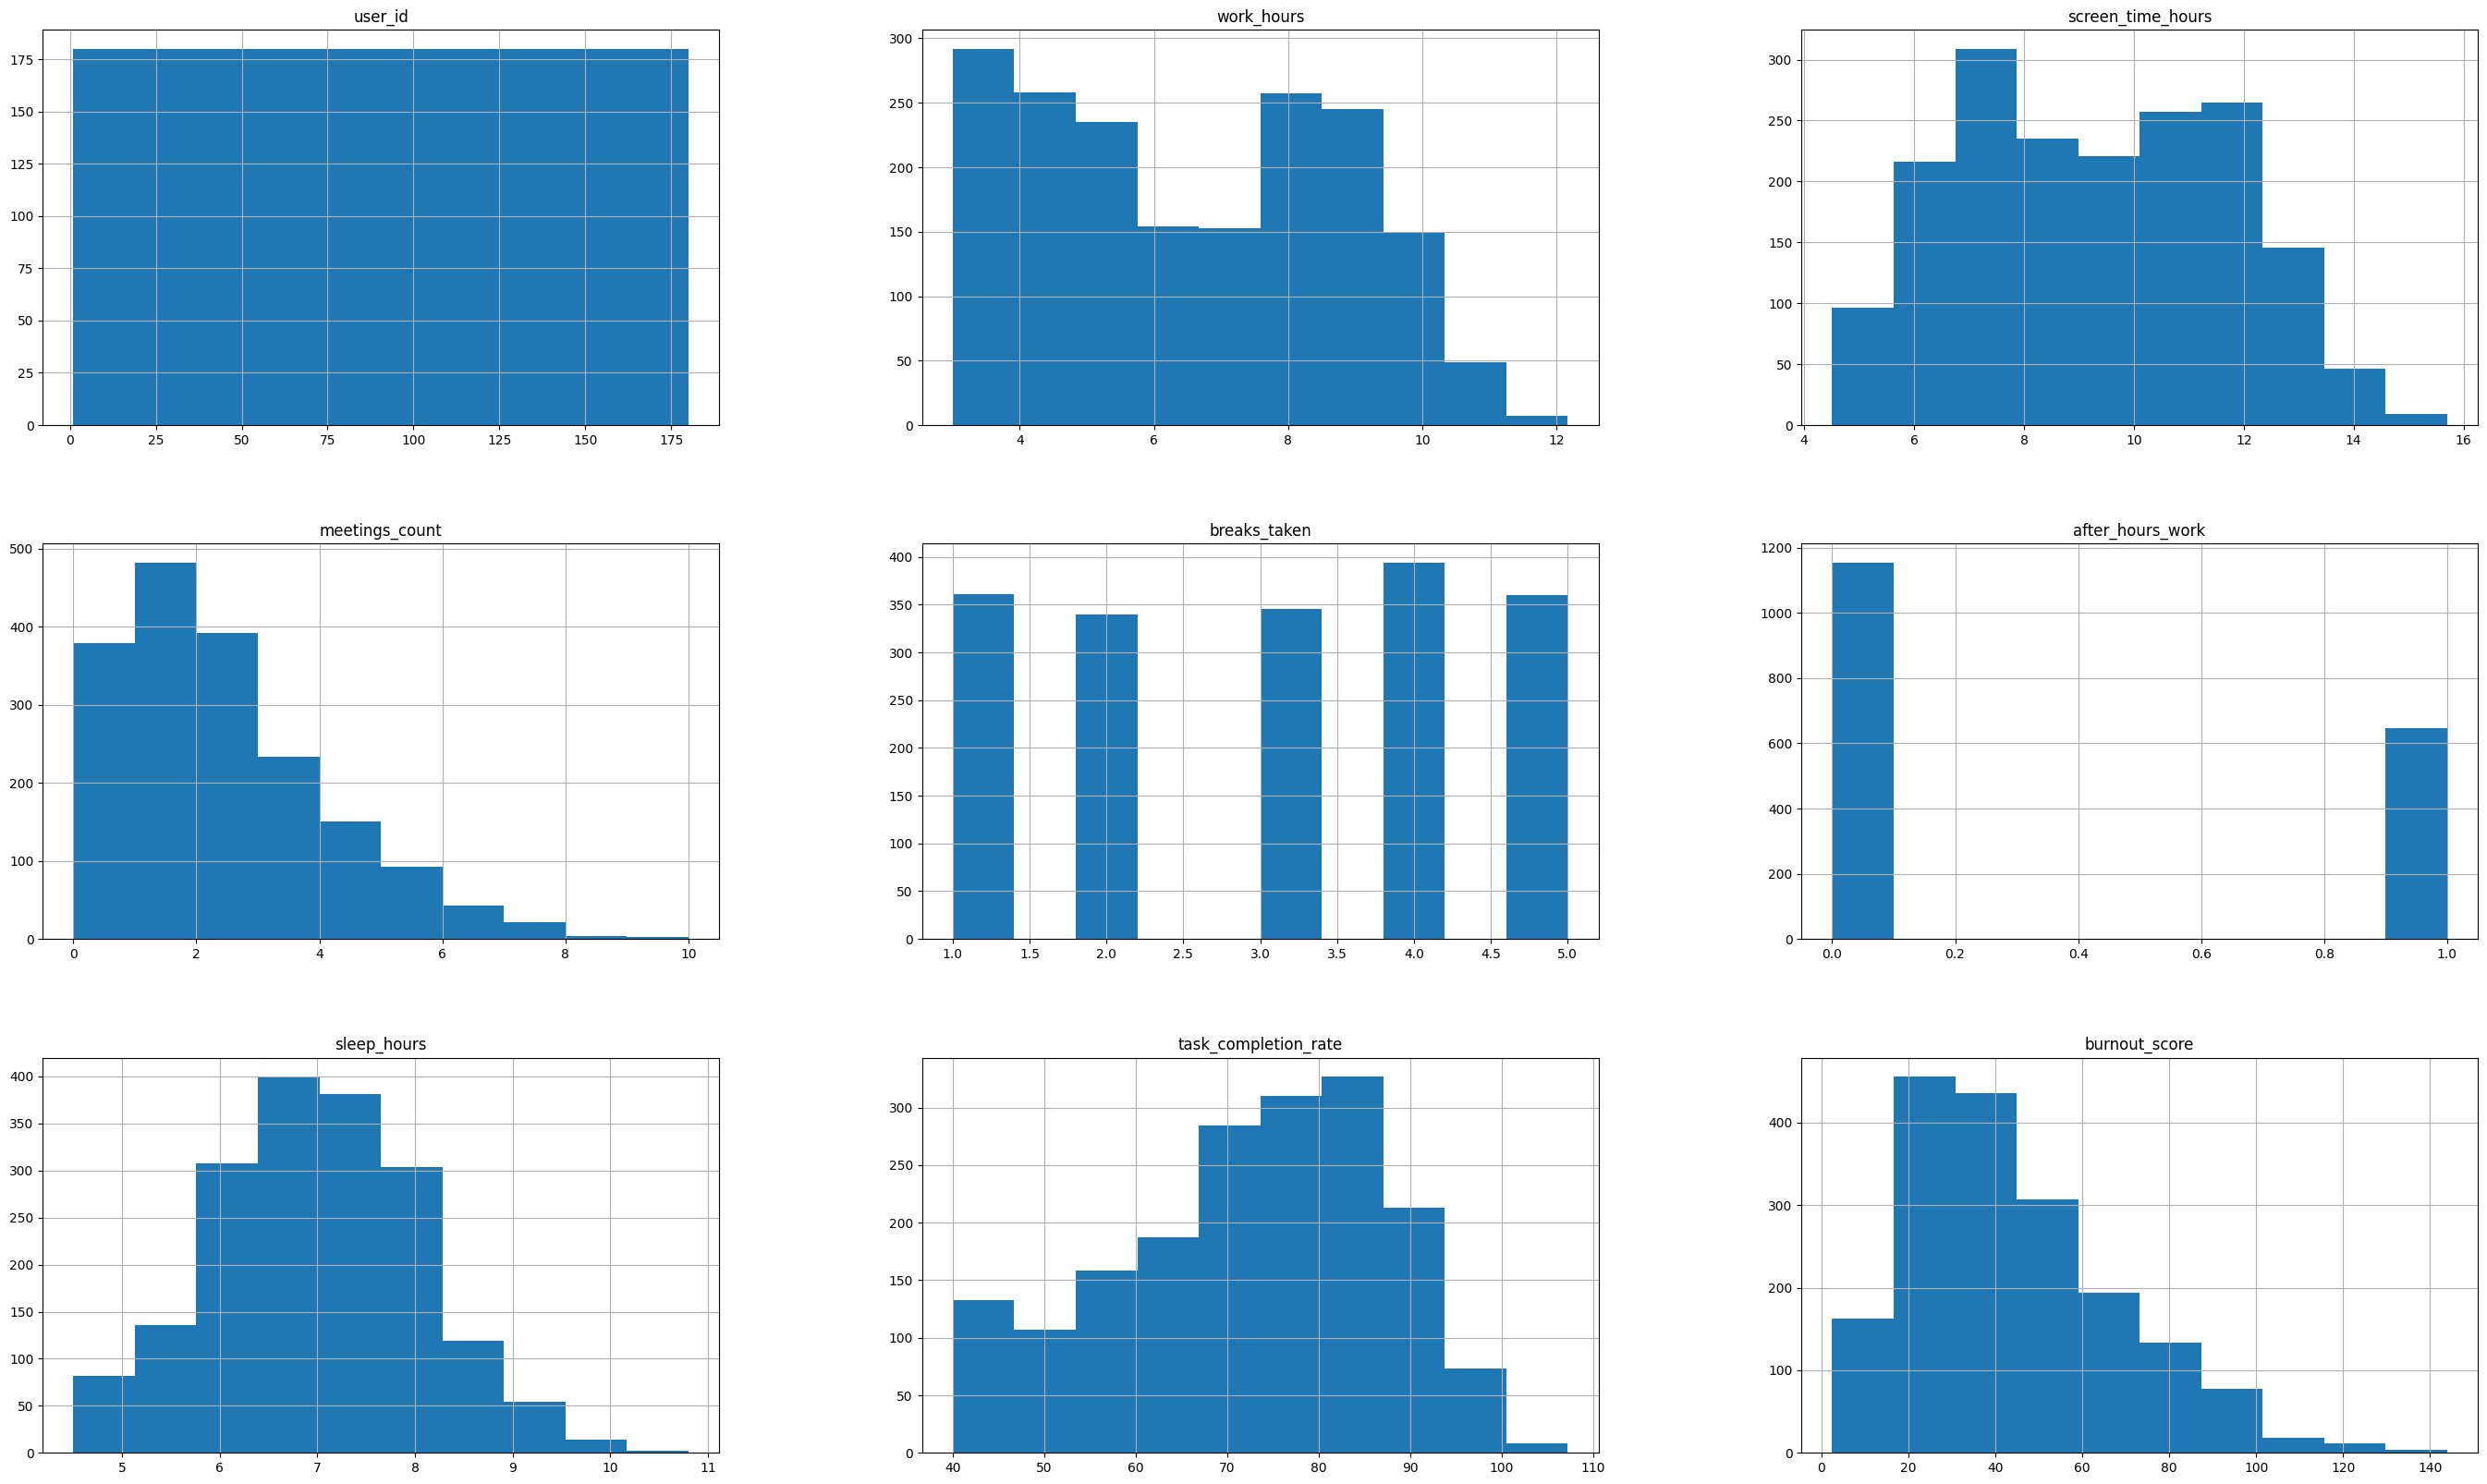

In [18]:
df[num_cols].hist(figsize=(34,20))
plt.show()


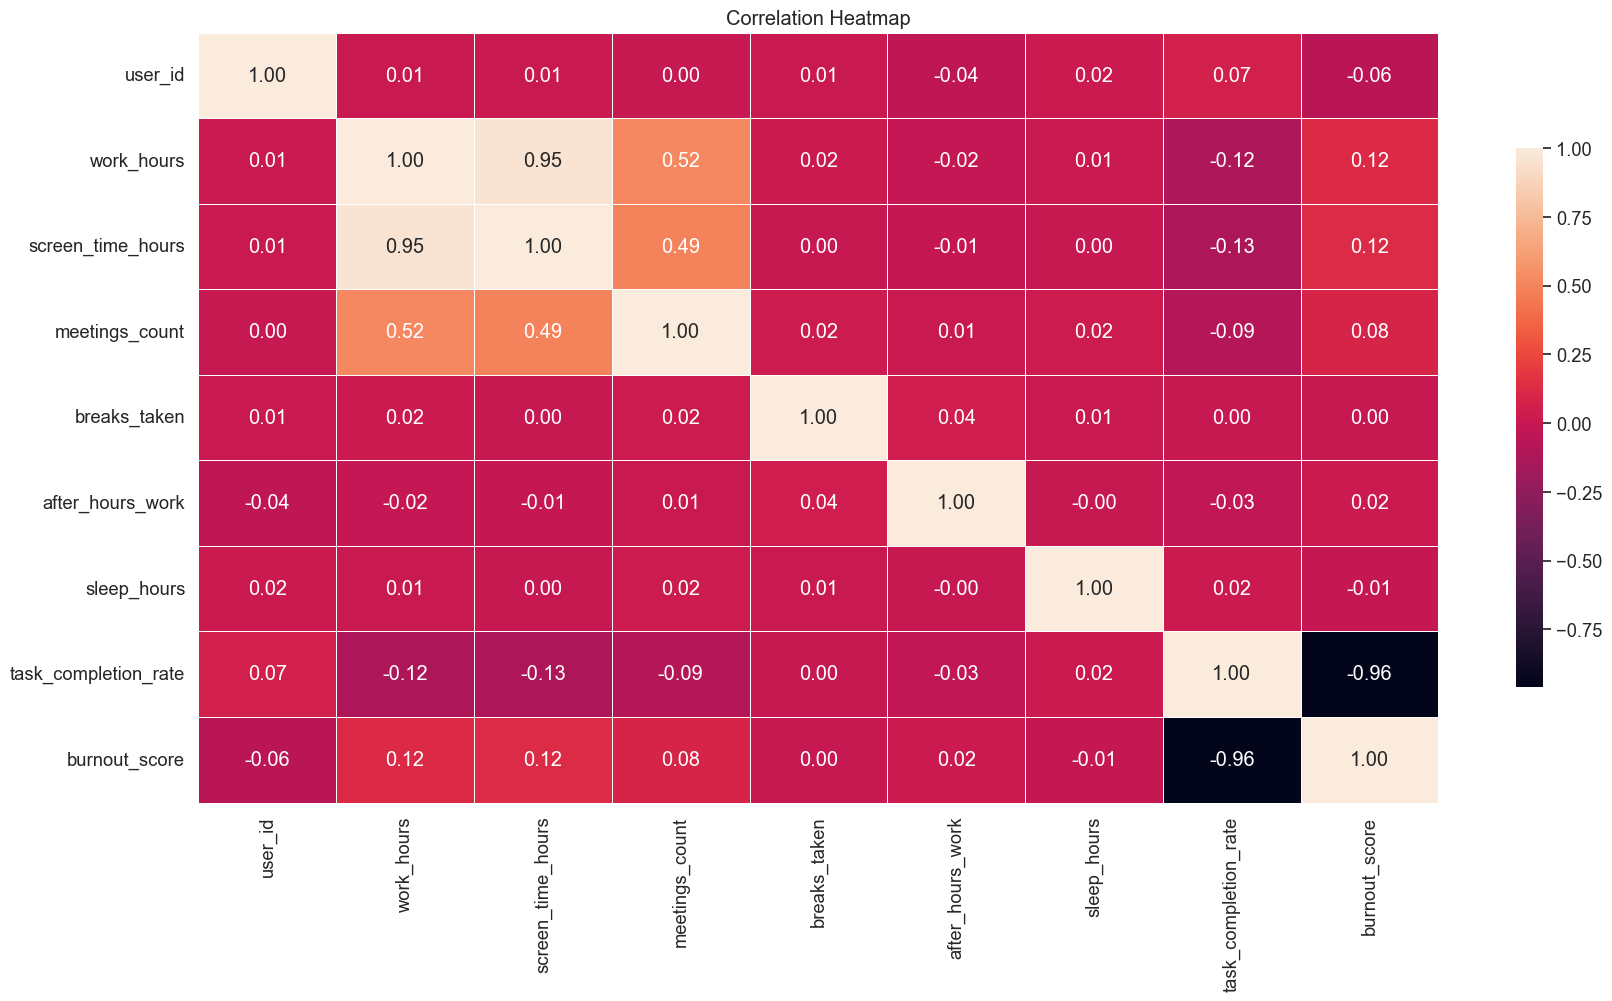

In [19]:

plt.figure(figsize=(20,10))
sns.set_style('whitegrid')
sns.set_context("notebook", font_scale=1.2)

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink':0.7}
)
plt.title('Correlation Heatmap')
plt.show()

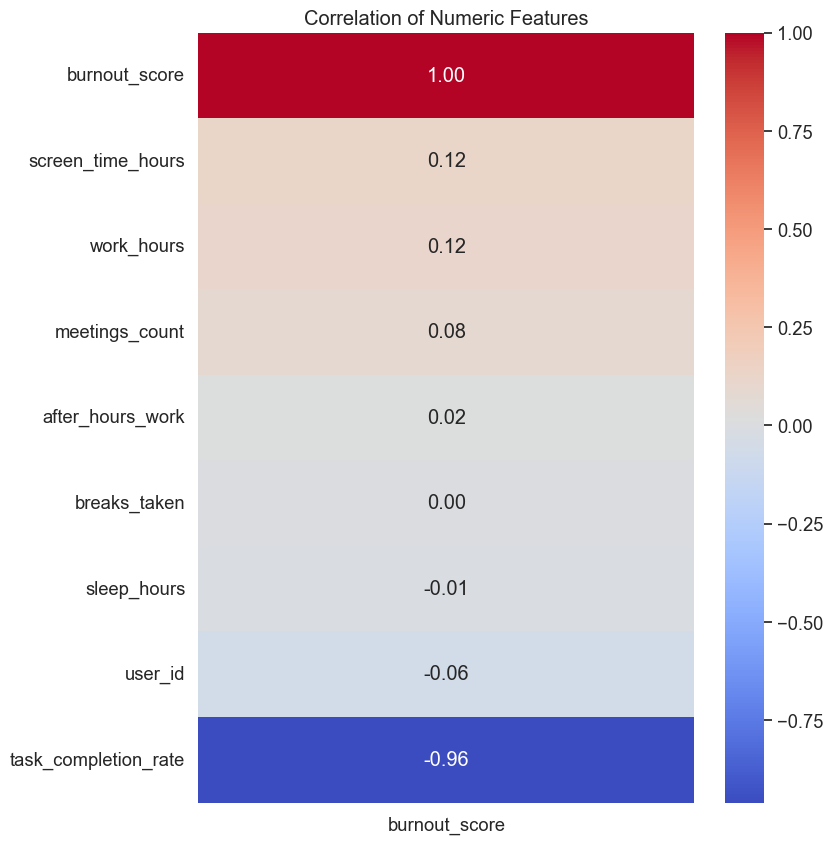

In [20]:
# 1. Calculate correlation for all numeric columns
# Ensure 'churned' is numeric (0 and 1) for this to work
corr_matrix = df.corr(numeric_only=True)

# 2. Isolate the correlation with the target 'churned'
# We sort the values to make the heatmap easier to read
score_corr = corr_matrix[['burnout_score']].sort_values(by='burnout_score', ascending=False)

# 3. Plotting
plt.figure(figsize=(8, 10))
sns.heatmap(score_corr, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            cbar=True)

plt.title('Correlation of Numeric Features')
plt.show()

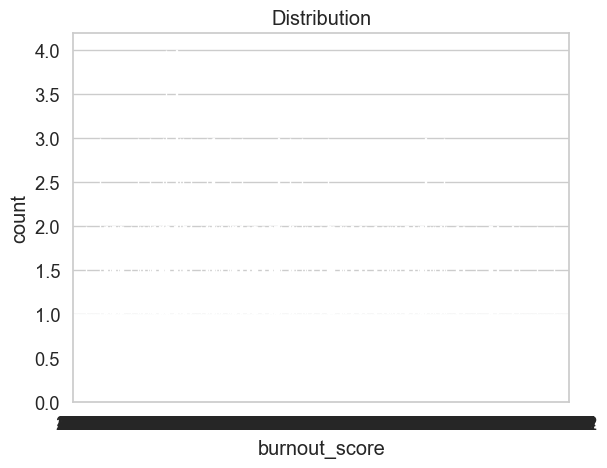

In [21]:
if 'burnout_score' in df.columns:
    sns.countplot(x='burnout_score', data=df)
    plt.title('Distribution')
    plt.show()

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron 
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split   


In [23]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [24]:

df_reduced = df.copy()

X = df_reduced.drop('burnout_score', axis=1)
y = df_reduced['burnout_score']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [26]:
# train test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, 
    y, 
    test_size=0.2, 
    random_state=42
)


In [30]:
from sklearn.model_selection import GridSearchCV, RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# Define Repeated K-Fold (for regression, since StratifiedKFold requires discrete classes)
X, y = X_train, y_train

rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

# -------------------------
# Pipelines
# -------------------------
pipelines = {
    'SVR': Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor())
    ]),
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('linreg', LinearRegression())
    ]),
    'AdaBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('ada', AdaBoostRegressor(random_state=42))
    ]),
    'GradientBoosting': Pipeline([
        ('scaler', StandardScaler()),
        ('gb', GradientBoostingRegressor(random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('scaler', StandardScaler()),
        ('dt', DecisionTreeRegressor(random_state=42))
    ])
}

# -------------------------
# Parameter Grids
# -------------------------
param_grids = {
    'SVR': {
        'svr__C': [0.1, 1, 10],
        'svr__kernel': ['linear', 'rbf'],
        'svr__gamma': ['scale', 'auto']
    },
    'KNN': {
        'knn__n_neighbors': [3, 5, 7, 9],
        'knn__weights': ['uniform', 'distance'],
        'knn__p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
    },
    'LinearRegression': {
        # LinearRegression has few hyperparameters; you can add regularization if needed
        'linreg__fit_intercept': [True, False]
    },
    'AdaBoost': {
        'ada__n_estimators': [50, 100, 200],
        'ada__learning_rate': [0.01, 0.1, 1.0]
    },
    'GradientBoosting': {
        'gb__n_estimators': [50, 100, 200],
        'gb__learning_rate': [0.01, 0.1, 0.2],
        'gb__max_depth': [3, 5, 7]
    },
    'DecisionTree': {
        'dt__max_depth': [None, 5, 10, 15],
        'dt__min_samples_split': [2, 5, 10],
        'dt__min_samples_leaf': [1, 2, 4]
    }
}

# -------------------------
# Grid Search for each model
# -------------------------
best_models = {}
for name in pipelines:
    print(f"Running GridSearchCV for {name}...")
    grid_search = GridSearchCV(
        estimator=pipelines[name],
        param_grid=param_grids[name],
        cv=rkf,
        scoring='neg_mean_squared_error',  # Use regression metric
        n_jobs=-1
    )
    grid_search.fit(X, y)
    best_models[name] = {
        'best_estimator': grid_search.best_estimator_,
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_
    }

# -------------------------
# Print results
# -------------------------
for name, info in best_models.items():
    print("\n------------------------")
    print(f"Model: {name}")
    print(f"Best Neg MSE: {info['best_score']:.4f}")
    print(f"Best Parameters: {info['best_params']}")

Running GridSearchCV for SVR...
Running GridSearchCV for KNN...
Running GridSearchCV for LinearRegression...
Running GridSearchCV for AdaBoost...
Running GridSearchCV for GradientBoosting...
Running GridSearchCV for DecisionTree...

------------------------
Model: SVR
Best Neg MSE: -52.8548
Best Parameters: {'svr__C': 10, 'svr__gamma': 'scale', 'svr__kernel': 'linear'}

------------------------
Model: KNN
Best Neg MSE: -78.8706
Best Parameters: {'knn__n_neighbors': 5, 'knn__p': 2, 'knn__weights': 'distance'}

------------------------
Model: LinearRegression
Best Neg MSE: -47.1695
Best Parameters: {'linreg__fit_intercept': True}

------------------------
Model: AdaBoost
Best Neg MSE: -33.1084
Best Parameters: {'ada__learning_rate': 0.1, 'ada__n_estimators': 100}

------------------------
Model: GradientBoosting
Best Neg MSE: -30.4387
Best Parameters: {'gb__learning_rate': 0.1, 'gb__max_depth': 3, 'gb__n_estimators': 50}

------------------------
Model: DecisionTree
Best Neg MSE: -33.862